In [7]:
# Install the UCI repo package
!pip install ucimlrepo

from ucimlrepo import fetch_ucirepo
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Fetch the dataset
dataset = fetch_ucirepo(id=296)
df = pd.DataFrame(dataset.data.features)
df['readmitted'] = dataset.data.targets

/usr/local/lib/python3.12/dist-packages/ucimlrepo/fetch.py:97: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(data_url)


In [8]:
# Explore data

print(f"Shape: {df.shape}")
print(f"\nColumn types:\n{df.dtypes.value_counts()}")
print(f"\nMissing values:\n{df.isnull().sum()[df.isnull().sum() > 0]}")
print(f"\nTarget distribution:\n{df['readmitted'].value_counts(normalize=True)}")


Shape: (101766, 48)

Column types:
object    37
int64     11
Name: count, dtype: int64

Missing values:
race                  2273
weight               98569
payer_code           40256
medical_specialty    49949
diag_1                  21
diag_2                 358
diag_3                1423
max_glu_serum        96420
A1Cresult            84748
dtype: int64

Target distribution:
readmitted
NO     0.539119
>30    0.349282
<30    0.111599
Name: proportion, dtype: float64


In [9]:
# Check for '?' which this dataset uses instead of NaN
for col in df.columns:
    if df[col].dtype == 'object':
        q_count = (df[col] == '?').sum()
        if q_count > 0:
            print(f"{col}: {q_count} missing values marked as '?'")

In [10]:
import os

# Create the 'images' directory if it doesn't exist
if not os.path.exists('images'):
    os.makedirs('images')

## **Key things to investigate:**
- Target class balance (expect imbalanced — far fewer readmissions)
- Which columns have excessive missing values
- Distribution of age, time_in_hospital, num_medications
- Relationship between number of diagnoses and readmission

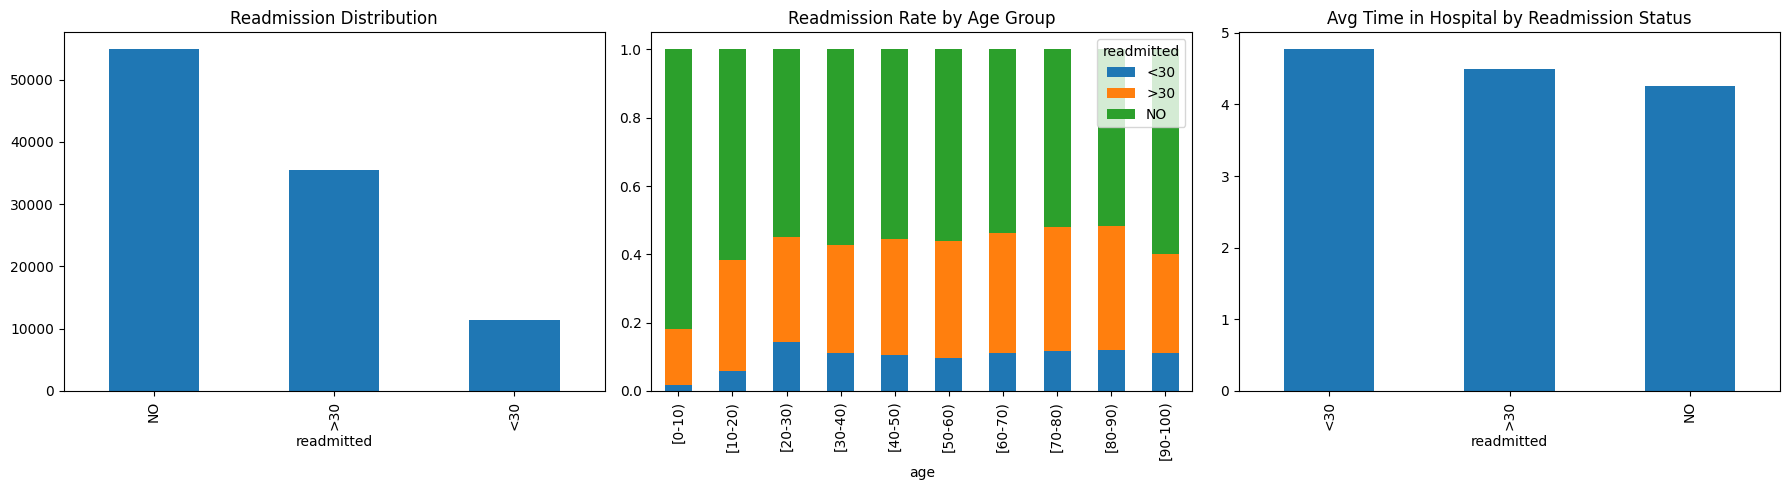

In [11]:
#Visualization

# Target distribution
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Readmission rates
df['readmitted'].value_counts().plot(kind='bar', ax=axes[0])
axes[0].set_title('Readmission Distribution')

# 2. Age vs readmission
pd.crosstab(df['age'], df['readmitted'], normalize='index').plot(
    kind='bar', stacked=True, ax=axes[1])
axes[1].set_title('Readmission Rate by Age Group')

# 3. Time in hospital
df.groupby('readmitted')['time_in_hospital'].mean().plot(
    kind='bar', ax=axes[2])
axes[2].set_title('Avg Time in Hospital by Readmission Status')

plt.tight_layout()
plt.savefig('images/eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()



In [12]:
# Data preprocessing

# Replace '?' with NaN
df.replace('?', np.nan, inplace=True)

# Drop columns with too many missing values (>40%)
threshold = 0.4
cols_to_drop = [col for col in df.columns
                if df[col].isnull().mean() > threshold]
print(f"Dropping columns: {cols_to_drop}")
df.drop(columns=cols_to_drop, inplace=True)

# Drop columns that won't help prediction
drop_cols = ['encounter_id', 'patient_nbr']  # IDs, not features
df.drop(columns=[c for c in drop_cols if c in df.columns], inplace=True)

# Handle duplicate patients — keep first encounter only
if 'patient_nbr' in df.columns:
    df = df.drop_duplicates(subset='patient_nbr', keep='first')

Dropping columns: ['weight', 'medical_specialty', 'max_glu_serum', 'A1Cresult']


In [13]:
# Engineer the target variable

# Binarise: 1 = readmitted within 30 days, 0 = not
df['readmitted_binary'] = (df['readmitted'] == '<30').astype(int)
df.drop(columns=['readmitted'], inplace=True)

print(f"Readmitted within 30 days: {df['readmitted_binary'].mean():.2%}")

Readmitted within 30 days: 11.16%


In [14]:
# Feature Engineering

# Total number of diagnoses recorded
diag_cols = [c for c in df.columns if c.startswith('diag_')]

# Number of medication changes
med_cols = [c for c in df.columns if df[c].dtype == 'object'
            and c not in ['race', 'gender', 'age']]

# Create useful aggregated features
df['num_medications_changed'] = df[med_cols].apply(
    lambda row: (row == 'Up').sum() + (row == 'Down').sum(), axis=1)

df['total_visits'] = (df.get('number_outpatient', 0) +
                      df.get('number_emergency', 0) +
                      df.get('number_inpatient', 0))

In [15]:
display(df.head())

,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,num_lab_procedures,num_procedures,...,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted_binary,num_medications_changed,total_visits
0,Caucasian,Female,[0-10),6,25,1,1,NaN,41,0,...,No,No,No,No,No,No,No,0,0,0
1,Caucasian,Female,[10-20),1,1,7,3,NaN,59,0,...,No,No,No,No,No,Ch,Yes,0,1,0
2,AfricanAmerican,Female,[20-30),1,1,7,2,NaN,11,5,...,No,No,No,No,No,No,Yes,0,0,3
3,Caucasian,Male,[30-40),1,1,7,2,NaN,44,1,...,No,No,No,No,No,Ch,Yes,0,1,0
4,Caucasian,Male,[40-50),1,1,7,1,NaN,51,0,...,No,No,No,No,No,Ch,Yes,0,0,0


In [16]:
# Encode categorical variables

from sklearn.preprocessing import LabelEncoder, StandardScaler

# Identify categorical and numerical columns
cat_cols = df.select_dtypes(include='object').columns.tolist()
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
num_cols.remove('readmitted_binary')  # Don't scale the target

# Encode categoricals
le_dict = {}
for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    le_dict[col] = le

# Scale numerical features
scaler = StandardScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])

In [17]:
# Train/test splits

from sklearn.model_selection import train_test_split

X = df.drop(columns=['readmitted_binary'])
y = df['readmitted_binary']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Train readmission rate: {y_train.mean():.2%}")
print(f"Test readmission rate: {y_test.mean():.2%}")

Train: (81412, 45), Test: (20354, 45)
Train readmission rate: 11.16%
Test readmission rate: 11.16%


In [18]:
# Handle class imbalance

# Option A: SMOTE (recommended for this dataset)
!pip install imbalanced-learn

from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)
print(f"After SMOTE: {y_train_res.value_counts()}")

After SMOTE: readmitted_binary
0    72326
1    72326
Name: count, dtype: int64


In [19]:
# Train multiple models

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (classification_report, roc_auc_score,
                             confusion_matrix, roc_curve)
import xgboost as xgb

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=200, random_state=42,
                                            n_jobs=-1),
    'XGBoost': xgb.XGBClassifier(n_estimators=200, max_depth=6,
                                  learning_rate=0.1, random_state=42,
                                  eval_metric='logloss')
}

results = {}

for name, model in models.items():
    print(f"\nTraining {name}...")
    model.fit(X_train_res, y_train_res)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    auc = roc_auc_score(y_test, y_prob)
    results[name] = {
        'model': model,
        'predictions': y_pred,
        'probabilities': y_prob,
        'auc': auc
    }
    print(f"{name} — AUC-ROC: {auc:.4f}")
    print(classification_report(y_test, y_pred))


Training Logistic Regression...


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression — AUC-ROC: 0.5608
              precision    recall  f1-score   support

           0       0.90      0.78      0.83     18083
           1       0.15      0.31      0.20      2271

    accuracy                           0.73     20354
   macro avg       0.52      0.54      0.52     20354
weighted avg       0.82      0.73      0.76     20354


Training Random Forest...
Random Forest — AUC-ROC: 0.6320
              precision    recall  f1-score   support

           0       0.89      1.00      0.94     18083
           1       0.48      0.02      0.05      2271

    accuracy                           0.89     20354
   macro avg       0.69      0.51      0.49     20354
weighted avg       0.84      0.89      0.84     20354


Training XGBoost...
XGBoost — AUC-ROC: 0.6703
              precision    recall  f1-score   support

           0       0.89      1.00      0.94     18083
           1       0.49      0.02      0.04      2271

    accuracy                          

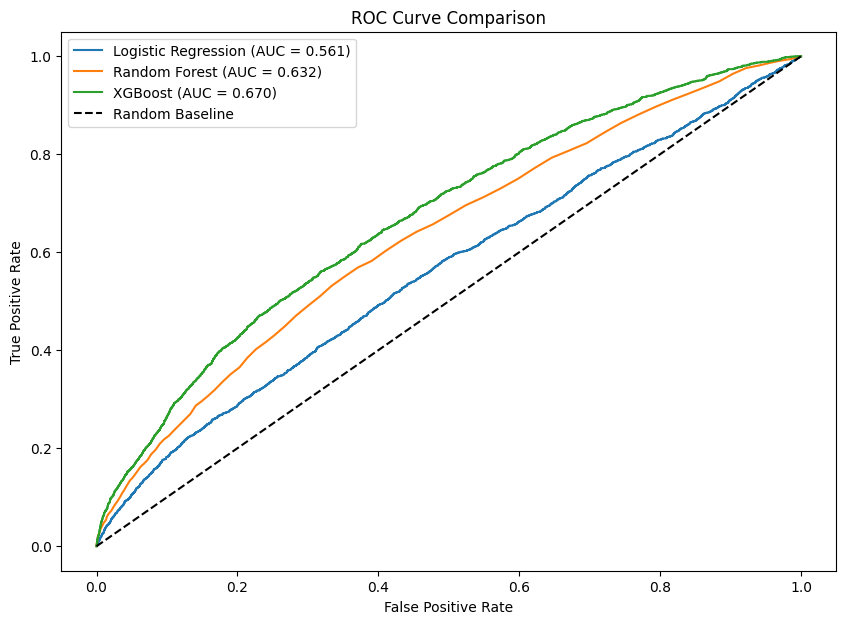

In [20]:
# Compare models visually

# ROC Curves
plt.figure(figsize=(10, 7))
for name, res in results.items():
    fpr, tpr, _ = roc_curve(y_test, res['probabilities'])
    plt.plot(fpr, tpr, label=f"{name} (AUC = {res['auc']:.3f})")

plt.plot([0, 1], [0, 1], 'k--', label='Random Baseline')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.savefig('images/roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()

## Analysis + SHAP Explainability

Best model: XGBoost


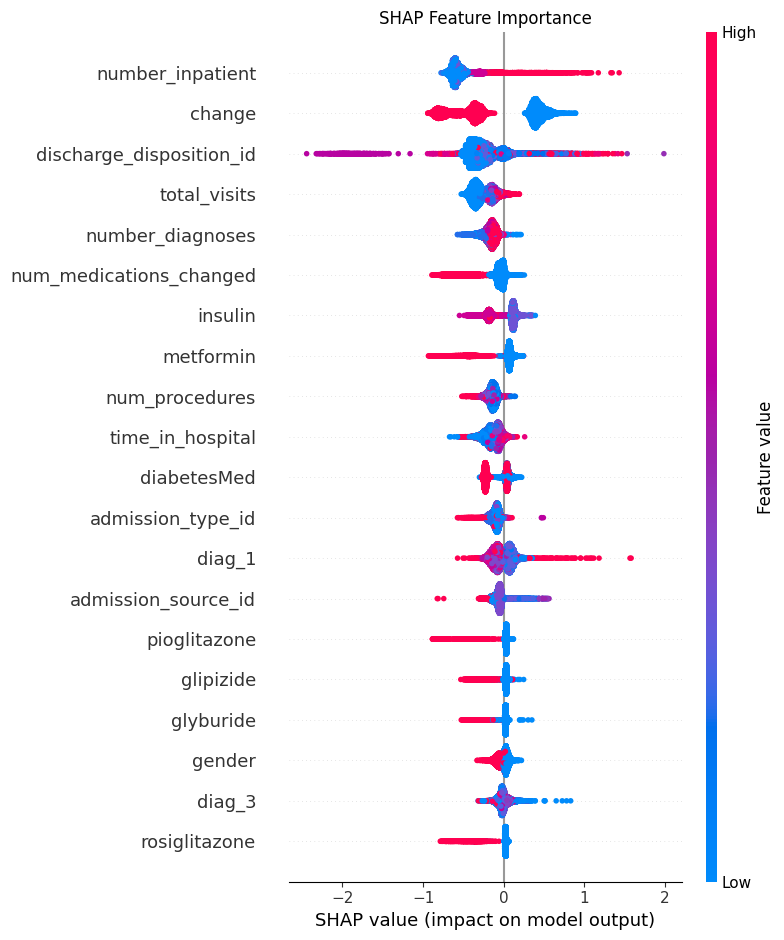

In [21]:
# Feature importance with SHAP
!pip install shap

import shap

# Use the best performing model (XGBoost)
best_model_name = max(results, key=lambda k: results[k]['auc'])
best_model = results[best_model_name]['model']
print(f"Best model: {best_model_name}")

# SHAP values
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)

# Summary plot
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_test, show=False)
plt.title('SHAP Feature Importance')
plt.tight_layout()
plt.savefig('images/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

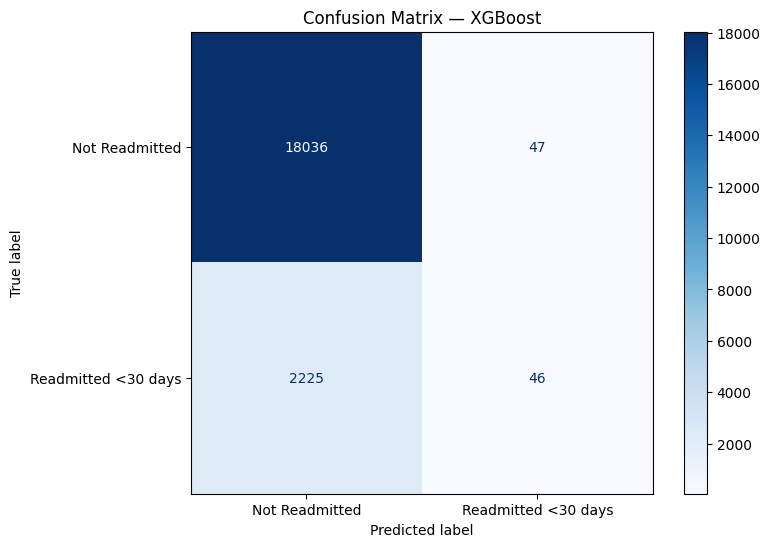

In [22]:
#  Confusion matrix for best model

from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test, results[best_model_name]['predictions'],
    display_labels=['Not Readmitted', 'Readmitted <30 days'],
    cmap='Blues', ax=ax)
ax.set_title(f'Confusion Matrix — {best_model_name}')
plt.savefig('images/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()